# SAMOS2026 Core3CS Project
## Group ASAYIKO
**Visualizing Remote-Sensed Ocean Colour Data**

Contributors: Koketso, Asanda, Yibanathi  
Date: 17 May 2026



## Introduction
This project combines multiple methods to analyze and visualize oceanographic data. 
We use ESA-CCI Ocean Colour climatology to study chlorophyll concentration, alongside bathymetry data to understand physical drivers of phytoplankton distribution. 
By integrating maps, time series, and metadata analysis, we aim to highlight seasonal cycles and spatial variability in coastal regions.



### Bathymetry mapping in St Helena Bay and Cape Columbine coastal regions

In [19]:
# Import packages
import xarray as xr
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors

# These packages will be used later
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

In [20]:
# Load bathymetry dataset downloaded from GMRT MapTool
bathy=xr.open_dataset('GMRTv4_4_1_20260513topo 1.grd')
bathy

<xarray.Dataset> Size: 80MB
Dimensions:   (lat: 3381, lon: 2949)
Coordinates:
  * lat       (lat) float64 27kB -33.77 -33.77 -33.77 ... -32.22 -32.22 -32.22
  * lon       (lon) float64 24kB 16.99 16.99 16.99 16.99 ... 18.61 18.61 18.61
Data variables:
    altitude  (lat, lon) float64 80MB ...
Attributes:
    title:        GMRT Grid
    history:      Projection: Cylindrical Equidistant\nExtracted from the Glo...
    Conventions:  COARDS,CF-1.6
    GMT_version:  4.5.7

In [21]:
# Import package to manage directories and file paths
import os
print(os.listdir("."))

['.ipynb_checkpoints', 'bathy st helena & cape columbine.png', 'Exercise5.ipynb', 'GMRTv4_4_1_20260513topo (1).grd', 'GMRTv4_4_1_20260513topo 1.grd']


### This package was obtained from Microsoft Copilot Ai 

In [22]:
# Import the package
import cmocean

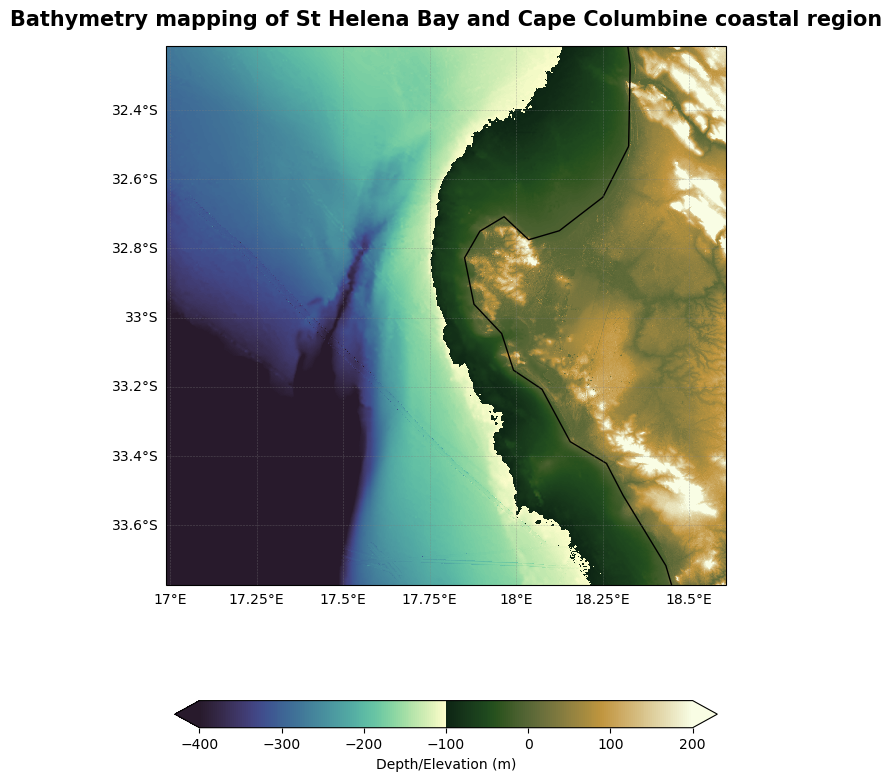

In [18]:
# Plot bathymetry of the coastal region using the PlateCarree projection
fig, axis = plt.subplots(
    1, 1, figsize=(10, 10),
    subplot_kw=dict(projection=ccrs.PlateCarree())  
)

# Plot bathymetry using cmocean's topo colormap
bathy['altitude'].plot(
    ax=axis,
    cmap=cmocean.cm.topo,
    vmin=-400,   # Focus on shelf and bay depths
    vmax=200,    # Keep coastal region visible but not exaggerated
    cbar_kwargs={"orientation": "horizontal", "shrink": 0.7,
                 'label':'Depth/Elevation (m)'},
    transform=ccrs.PlateCarree()
)      

axis.clabel(contours, inline=True, fontsize=8, fmt='%d m')

# Add coastlines
axis.coastlines(resolution='50m', color='black')

# Add gridlines showing only left and bottom labels
gl = axis.gridlines(draw_labels=True, linewidth=0.4,
                      color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Plot the bathymetry map
plt.title('Bathymetry mapping of St Helena Bay and Cape Columbine coastal region',
  fontsize=15,
    weight="bold",
    pad=15
         )                 
plt.savefig('bathy st helena & cape columbine coastal region.png', dpi=300, bbox_inches='tight')
plt.show()

**Figure 1:** Bathymetry mapping using GMRT MapTool downloaded file of St Helena Bay and Cape Columbine coastal regions

### Mean Annual Chlorophyll-a mapping in St Helena Bay and Cape Columbine coastal regions

The following figure shows chlorophyll-a concentration map of St Helena Bay and Cape Columbine Bay, approximately at 16.99°E–18.61°E and 33.77°S–32.22°S. The map shows how chlorophyll-a concentrations increase from offshore(represented in blue on the map due to low concentrations) towards the coast(represented in green-yellow color due to higher concentrations).

In [2]:
# Load ESA-CCI chlorophyll climatology dataset
chl = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")
chl

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHL...
    NCO:                               4.7.2
    nco_openmp_thread_number:          1
    CDO:                               Climate Data Operators version 1.9.3 (...

In [3]:
# Identification of chlorophyll variable
possible_names = ['chlor_a', 'chlorophyll', 'CHL', 'chl']

for name in possible_names:
    if name in chl.data_vars:
        chlorophyll = chl[name]
        print(f"Using variable: {name}")
        break

# Print variable summary
chlorophyll

Using variable: chlor_a


<xarray.DataArray 'chlor_a' (time: 12, lat: 4320, lon: 8640)> Size: 2GB
[447897600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3

In [8]:
# Compute annual mean chlorophyll concentration
annual_mean = chlorophyll.mean(dim='time')
annual_mean

<xarray.DataArray 'chlor_a' (lat: 4320, lon: 8640)> Size: 149MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(4320, 8640), dtype=float32)
Coordinates:
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3

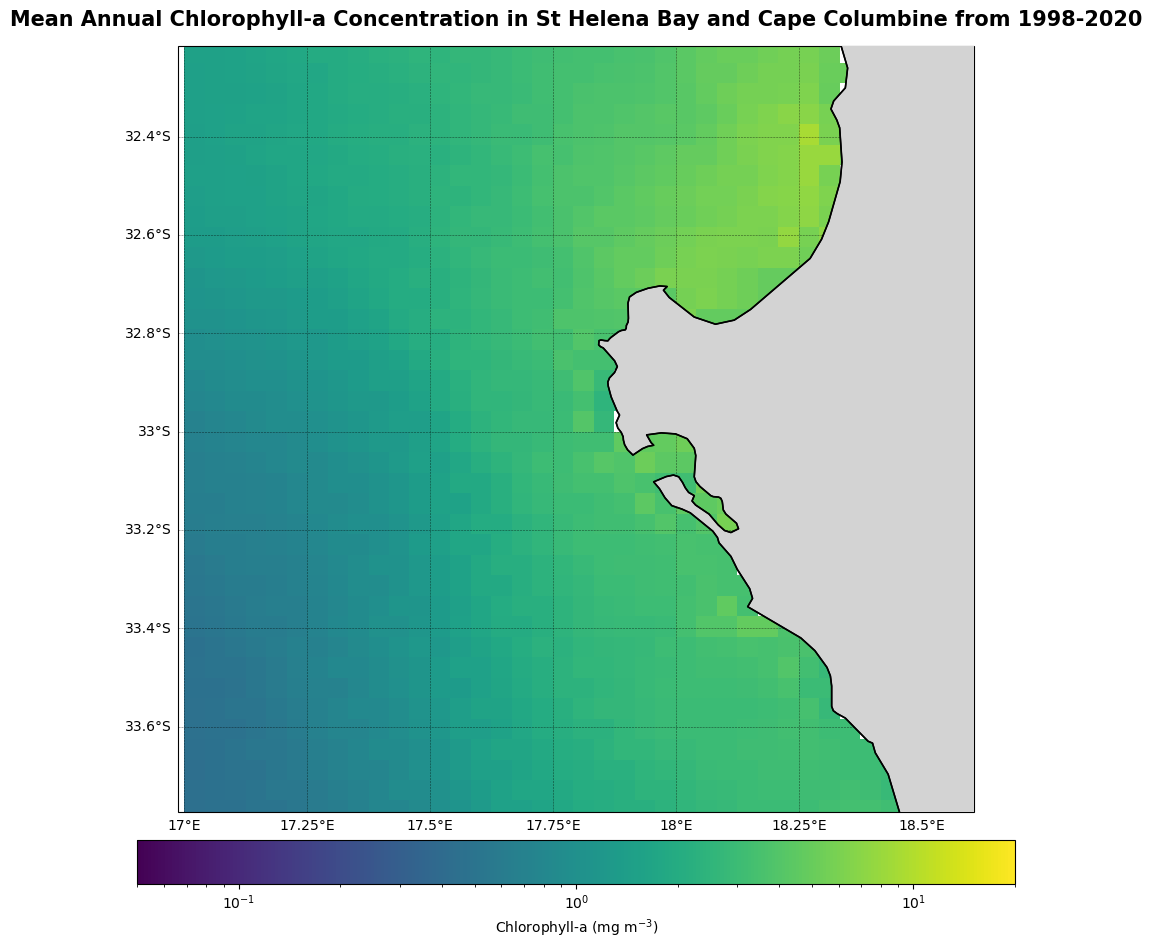

In [4]:
# Compute mean annual climatology
chl_mean = chl.mean(dim="time")

# St Helena Bay and Cape Columbine latitudes and longitudes
lon_min, lon_max = 16.9880, 18.6067
lat_min, lat_max = -33.7727, -32.2165

# Use loop function to compute latitude orientation 
if chl_mean.lat.values[0] > chl_mean.lat.values[-1]:
    st_helena = chl_mean.sel(
        lon=slice(lon_min, lon_max),
        lat=slice(lat_max, lat_min)
    )
else:
    st_helena = chl_mean.sel(
        lon=slice(lon_min, lon_max),
        lat=slice(lat_min, lat_max)
    )

# Remove invalid values
st_helena = st_helena.where(st_helena > 0)

# Create the figure
fig = plt.figure(figsize=(12,10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot mean annual chlorophyll-a concentration 
chl_plot = st_helena['chlor_a'].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    norm=LogNorm(vmin=0.05, vmax=20), # Log scale the plot to improve visibility
    rasterized=True,
    cbar_kwargs={
        "label": "Chlorophyll-a (mg m$^{-3}$)",
        "shrink": 0.75,
        "pad": 0.03,
        "orientation": "horizontal"
    }
)
            
# Add map extent
ax.set_extent(
    [lon_min, lon_max, lat_min, lat_max],
    crs=ccrs.PlateCarree()
)

# Add coastlines and land shading 
ax.add_feature(
    cfeature.LAND,
    facecolor="lightgray",
    edgecolor="black",
    zorder=10
)
ax.coastlines(
    resolution="10m",
    linewidth=1.2,
    color="black",
    zorder=11
)

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', color='black', alpha=0.6)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Add axis titles
ax.set_title(
    "Mean Annual Chlorophyll-a Concentration in St Helena Bay and Cape Columbine from 1998-2020",
    fontsize=15,
    weight="bold",
    pad=15

)
# Plot and save the mean annual chlorophyll-a conc
plt.tight_layout()
plt.savefig("mean annual chl.png", dpi=300, bbox_inches='tight')
plt.show()

**Figure 2:** Map representing the mean annual chlorophyll-a concentration in St Helena Bay and Cape Columbine from 1998-2020

## Monthly Chlorophyll-a Maps

The following faceted figure shows the climatological monthly mean chlorophyll-a 
concentration across the St Helena Bay–Cape Columbine region for each calendar month, 
derived from the ESA-CCI Ocean Colour dataset (1998–2020). The region spans 
16.99°E–18.61°E and 33.77°S–32.22°S, encompassing both the productive nearshore 
waters of St Helena Bay and the Cape Columbine upwelling cell to the south. 
Chlorophyll is displayed on a logarithmic scale to capture the wide dynamic range 
of phytoplankton biomass across the region.

Region shape (months, lat, lon): (12, 38, 39)
Valid ocean pixels in January: 1127


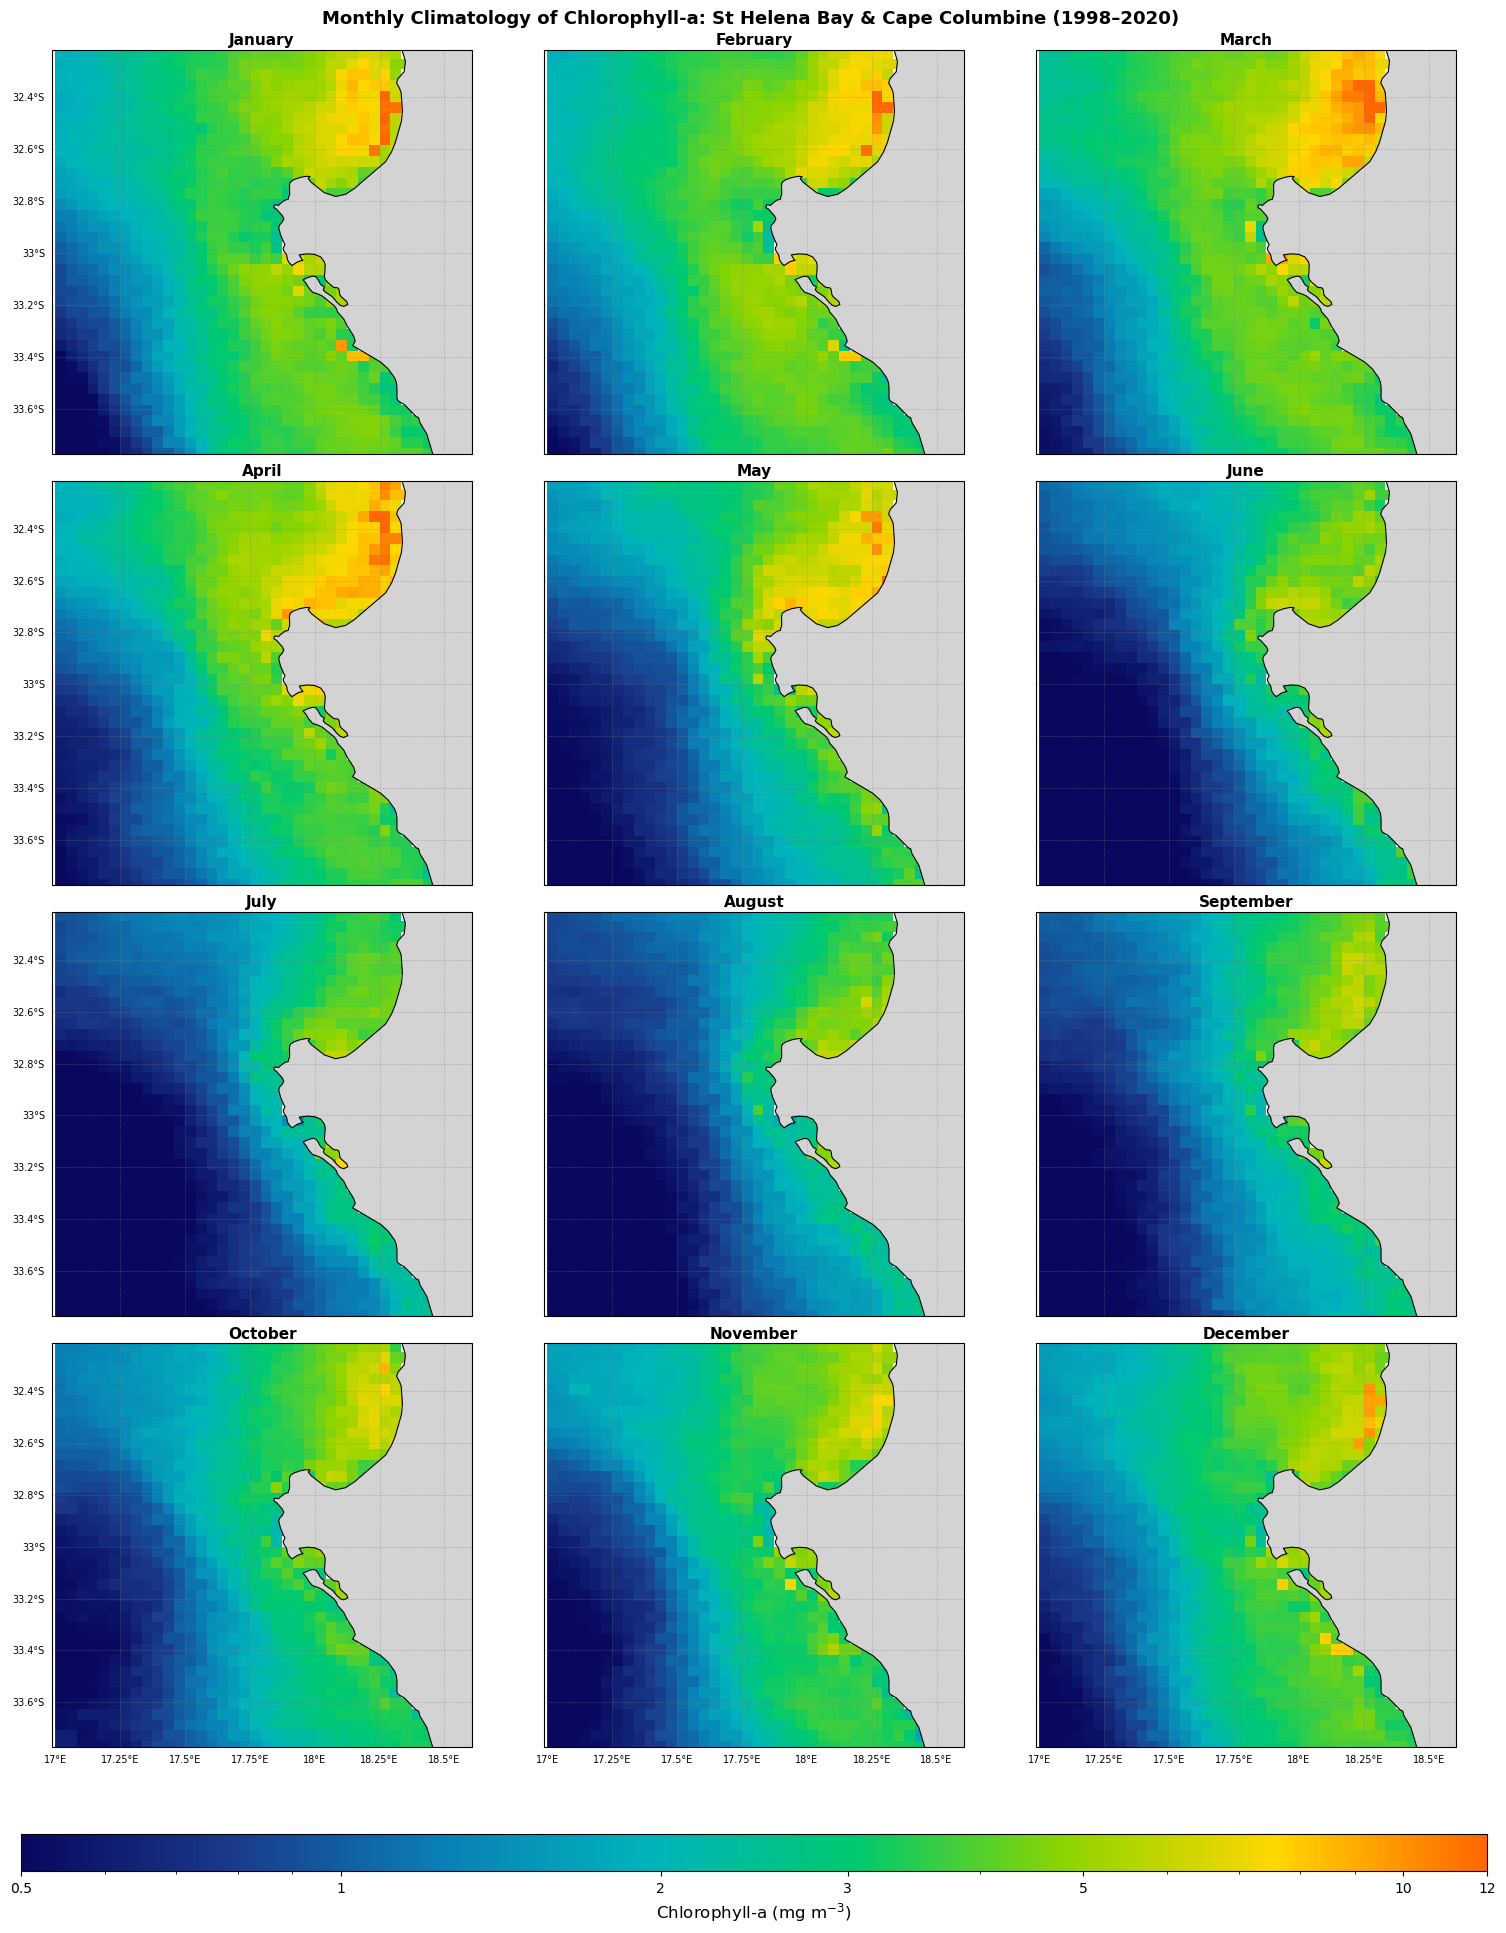

Figure saved as chl_monthly_maps_StHelenaBay.png


In [14]:
# Load the ESA-CCI chlorophyll climatology dataset
chl = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# These bounds are directly from our GMRT bathymetry downloaded file and define the St Helena Bay and Cape Columbine study region
lat_min, lat_max = -33.772755, -32.216054
lon_min, lon_max =  16.987610,  18.606995

# The ESA-CCI dataset stores latitude in descending order (90 to -90), pass lat_max first to get the correct spatial subset
chl_region = chl['chlor_a'].sel(
    lat=slice(lat_max, lat_min),
    
    lon=slice(lon_min, lon_max)
)

# Print subset data
print("Region shape (months, lat, lon):", chl_region.shape)
print("Valid ocean pixels in January:", int((~np.isnan(chl_region.isel(time=0))).sum()))

# Chlorophyll-a conc has multiple magnitude, so use a log colour scale and a range 0.5–12 mg/m³to represent productive Benguela upwelling region
vmin, vmax = 0.5, 12.0
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

# Use deep blue for low chlorophyll open ocean water and cyan and green to yellow for high coastal productivity
from matplotlib.colors import LinearSegmentedColormap

ocean_chl_colors = [
    '#08085e',  # very low  — deep navy (oligotrophic open ocean)
    '#1a3a8a',  # low       — royal blue
    '#0a7fb5',  # moderate  — ocean blue
    '#00b4bc',  # moderate  — cyan
    '#00c96e',  # elevated  — green
    '#8fd400',  # high      — yellow-green
    '#ffd700',  # very high — golden yellow
    '#ff6600',  # extreme   — orange (coastal upwelling peaks)
]
cmap = LinearSegmentedColormap.from_list('ocean_chl', ocean_chl_colors, N=256)

# Month names for the panel titles
months = ['January',   'February', 'March',    'April',
          'May',       'June',     'July',     'August',
          'September', 'October',  'November', 'December']

# Plot a 4-row by 3-column figure, one panel per month using Cartopy's PlateCarree projection to render the maps correctly
fig, axes = plt.subplots(
    nrows=4, ncols=3,
    figsize=(15, 19),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

# Flatten the 2D array of axes into a list to loop over it easily
axes_flat = axes.flatten()

for i in range(12):
    ax = axes_flat[i]

# Select the chlorophyll field for this particular month
    chl_month = chl_region.isel(time=i)

# Draw the chlorophyll field as a filled colour mesh on the map
    im = ax.pcolormesh(
        chl_month.lon.values,
        chl_month.lat.values,
        chl_month.values,
        norm=norm,
        cmap=cmap,
        transform=ccrs.PlateCarree()
    )

# Overlay land and coastline so the geography is clear
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8,          zorder=3)

# Restrict each panel to the study region extent
    ax.set_extent([lon_min, lon_max, lat_min, lat_max],
                  crs=ccrs.PlateCarree())

# Add gridlines, label the leftmost column and bottom row and to avoid overlapping tick labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                      color='gray', alpha=0.5, linestyle='--')
    gl.top_labels    = False
    gl.right_labels  = False
    gl.left_labels   = (i % 3 == 0)
    gl.bottom_labels = (i >= 9)
    gl.xlabel_style  = {'size': 7}
    gl.ylabel_style  = {'size': 7}

# Label each panel with the month name
    ax.set_title(months[i], fontsize=11, fontweight='bold', pad=4)

# Add a single shared colourbr
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    orientation='horizontal',
    fraction=0.03,
    pad=0.04,
    aspect=40
)
cbar.set_label('Chlorophyll-a (mg m$^{-3}$)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Set explicit tick positions on the log scale 
cbar.set_ticks([0.5, 1, 2, 3, 5, 10, 12])
cbar.set_ticklabels(['0.5', '1', '2', '3', '5', '10', '12'])

# Overall figure title
fig.suptitle(
    'Monthly Climatology of Chlorophyll-a: St Helena Bay & Cape Columbine (1998–2020)',
    fontsize=13, fontweight='bold', y=1.01
)

# Plot and save at 300 dpi 
plt.savefig("chl_monthly_maps_StHelenaBay.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved as chl_monthly_maps_StHelenaBay.png")

**Figure 3:** Monthly climatology of chlorophyll-a concentration (mg m⁻³) across 
St Helena Bay and Cape Columbine, South Africa 

### Time Series Analysis of Chlorophyll-a in St Helena Bay and Cape Columbine

To examine the seasonal variability of chlorophyll-a in St Helena Bay and Cape Columbine, we extract a 
regional subset of the ESA-CCI climatology bounded by 33.5°S–32.0°S and 17.5°E–19.0°E. 


In [ ]:
# Print latitudes direction
print("Lat min:", float(chl.lat.min()), "Lat max:", float(chl.lat.max()))
print("First few lat values:", chl.lat.values[:5])

# Print latitudes and longitudes
lat_min, lat_max = -33.5, -32.0
lon_min, lon_max = 17.5, 19.0

chl_region = chl['chlor_a'].sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))
print("Region shape:", chl_region.shape)
print("Non-NaN count:", int((~np.isnan(chl_region)).sum()))
print("Sample values:", chl_region.isel(time=0).values)

Selected grid point: -32.65°S, 17.73°E
Regional mean values: [4.46  4.647 5.144 4.94  3.916 2.635 2.222 2.324 2.747 3.245 3.555 3.81 ]
Single point values:  [3.616 4.233 4.518 4.709 3.542 2.084 1.56  1.73  2.037 2.711 3.412 3.34 ]


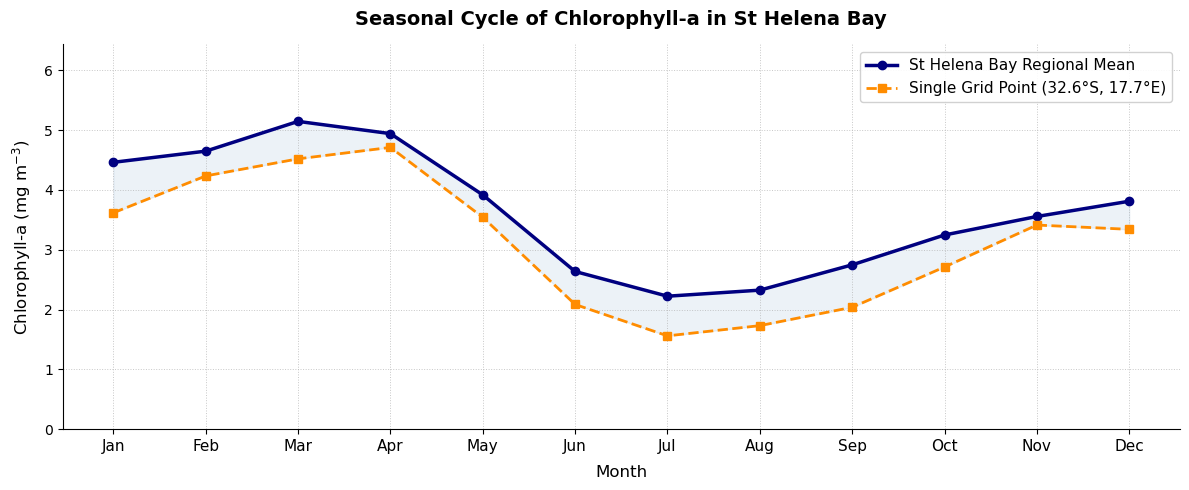

In [13]:
# Load ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY dataset
chl = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# Defined coastal region (St Helena Bay and Cape Columbine)
lat_min, lat_max = -33.5, -32.0
lon_min, lon_max = 17.5, 19.0

# lat_max first because dataset latitude runs descending (90 → -90)
chl_region = chl['chlor_a'].sel(
    lat=slice(lat_max, lat_min),
    lon=slice(lon_min, lon_max)
)

# Regional mean (ignores land/NaN pixels) 
chl_mean = chl_region.mean(dim=["lat", "lon"], skipna=True)

# Find a valid single grid point inside the study site and scan the region at time=0 to find the first non-NaN ocean pixel
sample = chl['chlor_a'].isel(time=0).sel(
    lat=slice(lat_max, lat_min),
    lon=slice(lon_min, lon_max)
)
valid = np.argwhere(~np.isnan(sample.values))

if len(valid) == 0:
    raise ValueError("No valid ocean pixels found in region — check bounds")

# Pick a point roughly in the middle of valid pixels 
mid = valid[len(valid) // 2]
point_lat = float(sample.lat[mid[0]])
point_lon = float(sample.lon[mid[1]])
print(f"Selected grid point: {point_lat:.2f}°S, {point_lon:.2f}°E")

chl_point = chl['chlor_a'].sel(lat=point_lat, lon=point_lon, method="nearest")

# Print values 
print("Regional mean values:", np.round(chl_mean.values, 3))
print("Single point values: ", np.round(chl_point.values, 3))

# Plot the monthly mean
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x = np.arange(1, 13)

mean_vals  = chl_mean.values
point_vals = chl_point.values

fig, ax = plt.subplots(figsize=(12, 5))

# Regional mean line
ax.plot(x, mean_vals,
        color='navy', linewidth=2.5,
        marker='o', markersize=6,
        label='St Helena Bay Regional Mean')

# Single grid point line
ax.plot(x, point_vals,
        color='darkorange', linewidth=2,
        linestyle='--', marker='s', markersize=6,
        label=f'Single Grid Point ({abs(point_lat):.1f}°S, {point_lon:.1f}°E)')

# Shaded band between the two lines
ax.fill_between(x, mean_vals, point_vals,
                alpha=0.10, color='steelblue')

# Add the axis
ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=11)
ax.set_xlabel("Month", fontsize=12, labelpad=8)
ax.set_ylabel("Chlorophyll-a (mg m$^{-3}$)", fontsize=12, labelpad=8)
ax.set_title("Seasonal Cycle of Chlorophyll-a in St Helena Bay",
             fontsize=14, fontweight='bold', pad=14)

# Safe y-axis upper limit
all_vals = np.concatenate([mean_vals, point_vals])
ymax = np.nanmax(all_vals) * 1.25
ymax = ymax if np.isfinite(ymax) else 8.0   # fallback
ax.set_ylim(0, ymax)

ax.legend(fontsize=11, framealpha=0.9, loc='upper right')
ax.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot and save the overall time series
plt.tight_layout()
plt.savefig("chl_timeseries_StHelenaBay.png", dpi=300, bbox_inches='tight')
plt.show()

**Figure 4:** Seasonal cycle of chlorophyll-a concentration (mg m⁻³) in St Helena Bay 
(17.5°–19.0°E, 33.5°–32.0°S) derived from ESA-CCI Ocean Colour climatology (1998–2020). 
The navy line shows the spatial mean over the region; the orange dashed line represents 
a single grid point at 32.6°S, 17.7°E. The shaded area highlights the difference between 
regional and local variability. Peak concentrations in March–April reflect enhanced 
phytoplankton growth associated with Benguela upwelling.